In [11]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

llm=HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-V3.2-Exp",
    task="text-generation"
)
model=ChatHuggingFace(llm=llm)

In [12]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float
    summary:str

In [50]:
def calculate_sr(state:BatsmanState):
    runs=state['runs']
    balls=state['balls']
    sr=(state['runs']/state['balls'])*100
    state['sr']=sr
    return {'sr':sr}

In [51]:
def calculate_bpb(state:BatsmanState):
    balls=state['balls']
    boundaries=state['fours']+state['sixes']

    bpb=balls/boundaries
    state['bpb']=bpb

    return {'bpb':bpb}

In [52]:
def calculate_boundary_percentage(state:BatsmanState):
    boundaries_score=state['fours']*4+state['sixes']*6
    runs=state['runs']

    boundary_percent=(boundaries_score/runs)*100
    state['boundary_percent']=boundary_percent

    return {'boundary_percent':state['boundary_percent']}

In [53]:
def summary(state:BatsmanState):
    summary=f"""
Strike rate -{state['sr']}\n
Balls per boundary - {state['bpb']}\n
boundary percent-{state['boundary_percent']}\n
"""
    state['summary']=summary
    return {'summar':summary}

In [54]:
grpah=StateGraph(BatsmanState)

grpah.add_node("calculate_sr",calculate_sr)
grpah.add_node("calculate_bpb",calculate_bpb)
grpah.add_node("calculate_boundary_percentage",calculate_boundary_percentage)
grpah.add_node("summary",summary)


#edges
grpah.add_edge(START,"calculate_sr")
grpah.add_edge(START,"calculate_bpb")
grpah.add_edge(START,"calculate_boundary_percentage")

grpah.add_edge("calculate_sr","summary")
grpah.add_edge("calculate_bpb","summary")
grpah.add_edge("calculate_boundary_percentage","summary")

grpah.add_edge("summary",END)

workflow=grpah.compile()

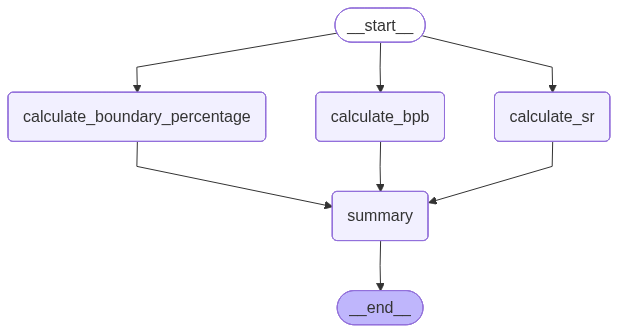

In [55]:
workflow

In [56]:
initial_state={"runs":100,"balls":50,"fours":6,"sixes":4}

final_state=workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0}
